<a href="https://colab.research.google.com/github/fecheromero/PNL_tps_Romero_Federico/blob/main/Romero_Federico_Desafio_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Custom embedddings con Gensim



### Objetivo
El objetivo es utilizar documentos / corpus para crear embeddings de palabras basado en ese contexto. Se utilizará canciones de bandas para generar los embeddings, es decir, que los vectores tendrán la forma en función de como esa banda haya utilizado las palabras en sus canciones.

In [156]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import multiprocessing
try:
  from gensim.models import Word2Vec
except:
  !pip install gensim
  from gensim.models import Word2Vec

# Consigna del desafío 2

**Cada experimento realizado debe estar acompañado de una explicación o interpretación de lo observado**

Recuerden que su notebook de entrega debe poder correrse de inicio a fin sin la aparición de errores.

## Crear sus propios vectores con Gensim basado en lo visto en clase con otro artista del dataset Songs.

Elegí realizar este desafío utilizando la discografía completa de Twenty One Pilots. La misma fue construida y cargada en un archivo ZIP que contiene varios archivos `.txt`, disponible en el siguiente enlace de Google Drive:

In [158]:
gdrive_zip_link = "https://drive.google.com/file/d/1_wG7v2ViDE9Ev9ORfufxywamRmrnBBbZ/view?usp=sharing"


In [159]:
import re

match = re.search(r'id=([a-zA-Z0-9_-]+)', gdrive_zip_link)
if match:
    file_id = match.group(1)
else:
    match = re.search(r'/file/d/([a-zA-Z0-9_-]+)', gdrive_zip_link)
    if match:
        file_id = match.group(1)
    else:
        file_id = None

if file_id:
    print(f'Extracted Google Drive File ID: {file_id}')
else:
    print('Could not extract Google Drive File ID from the provided link.')

Extracted Google Drive File ID: 1_wG7v2ViDE9Ev9ORfufxywamRmrnBBbZ


In [160]:
try:
    import gdown
except ModuleNotFoundError:
    !pip install gdown
    import gdown

output_path = 'songs_top.zip'
print(f'Attempting to download file with ID: {file_id} to {output_path}')
gdown.download(id=file_id, output=output_path, quiet=False)

Attempting to download file with ID: 1_wG7v2ViDE9Ev9ORfufxywamRmrnBBbZ to songs_top.zip


Downloading...
From: https://drive.google.com/uc?id=1_wG7v2ViDE9Ev9ORfufxywamRmrnBBbZ
To: /content/songs_top.zip
100%|██████████| 105k/105k [00:00<00:00, 64.9MB/s]


'songs_top.zip'

In [161]:
import os
import zipfile

zip_file_path = 'songs_top.zip'
extract_dir = 'songs_top'

if os.path.exists(zip_file_path):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print(f'Successfully extracted {zip_file_path} to {extract_dir}/')
else:
    print(f'Zip file not found at {zip_file_path}')

Successfully extracted songs_top.zip to songs_top/


In [162]:
import os

# Get a list of all files and directories within the 'songs_dataset' directory
all_files = os.listdir(extract_dir + '/letras top')

# Filter for files that end with '.txt'
lyrics_files = [f for f in all_files if f.endswith('.txt')]

print(f"Found {len(lyrics_files)} .txt files in '{extract_dir}':")
print(lyrics_files[:5]) # Print the first 5 files as an example

Found 101 .txt files in 'songs_top':
['Slowtown.txt', 'Formidable.txt', 'At_the_Risk_of_Feeling_Dumb.txt', 'Neon_Gravestones.txt', 'Before_You_Start_Your_Day.txt']


In [163]:
all_lyrics = []

for file_name in lyrics_files:
    file_path = os.path.join(extract_dir + "/letras top", file_name)
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                stripped_line = line.strip()
                if stripped_line:
                    all_lyrics.append(stripped_line)
    except Exception as e:
        print(f"Error reading {file_name}: {e}")

print(f"Total {len(all_lyrics)} lyric lines collected from all files.")

Total 4195 lyric lines collected from all files.


In [164]:
import pandas as pd

df_lyrics = pd.DataFrame(all_lyrics, columns=['lyrics'])
df_lyrics.head(15)

,lyrics
0,Slowtown
1,========
2,"Hey, heyWouldn't it be great, greatIf we could..."
3,Formidable
4,==========
5,You are formidable to me
6,'Cause you seem to know it where you wanna go
7,"Yeah, yeah, yeah, I'll follow you"
8,But you should know I might be cynical towards...
9,But I just can't believe that I'm for you


### 1 - Preprocesamiento

In [165]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence

sentence_tokens = []
# Recorrer todas las filas y transformar las oraciones
# en una secuencia de palabras (esto podría realizarse con NLTK o spaCy también)
for _, row in df_lyrics[:None].iterrows():
    sentence_tokens.append(text_to_word_sequence(row[0]))

/tmp/ipykernel_4792/3779292677.py:7: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



In [166]:
# Demos un vistazo
sentence_tokens[:12]

[['slowtown'],
 [],
 ['hey',
  "heywouldn't",
  'it',
  'be',
  'great',
  'greatif',
  'we',
  'could',
  'just',
  'lay',
  'downand',
  'wake',
  'up',
  'in',
  'slowtown',
  'today',
  'dayi',
  'wanna',
  'go',
  'away',
  'waycause',
  'things',
  'are',
  'too',
  'fast',
  'nowi',
  'wanna',
  'be',
  'in',
  'slowtowni',
  'put',
  'my',
  'socks',
  'on',
  'my',
  'feetjust',
  'so',
  'that',
  'my',
  'soul',
  "won't",
  'fall',
  'through',
  'my',
  'toesand',
  'i',
  'walk',
  'through',
  'my',
  'doorjust',
  'so',
  'i',
  "don't",
  'fall',
  'through',
  'the',
  'floori',
  'remember',
  'when',
  'my',
  'brother',
  'and',
  'other',
  'kids',
  'from',
  'neighboring',
  'houseswould',
  'get',
  'together',
  "i'd",
  'ride',
  'my',
  'bike',
  'and',
  'my',
  'brother',
  'would',
  'ride',
  'hisput',
  'cards',
  'in',
  'our',
  'spokes',
  'and',
  'make',
  'our',
  'engines',
  'sound',
  'like',
  'trafficwhen',
  'using',
  'pokemon',
  'cards',


### 2 - Crear los vectores (word2vec)

In [168]:
from gensim.models.callbacks import CallbackAny2Vec
# Durante el entrenamiento gensim por defecto no informa el "loss" en cada época
# Sobrecargamos el callback para poder tener esta información
class callback(CallbackAny2Vec):
    """
    Callback to print loss after each epoch
    """
    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print('Loss after epoch {}: {}'.format(self.epoch, loss))
        else:
            print('Loss after epoch {}: {}'.format(self.epoch, loss- self.loss_previous_step))
        self.epoch += 1
        self.loss_previous_step = loss

In [169]:
# Crearmos el modelo generador de vectores
# En este caso utilizaremos la estructura modelo Skipgram
w2v_model = Word2Vec(min_count=5,    # frecuencia mínima de palabra para incluirla en el vocabulario
                     window=4,       # cant de palabras antes y desp de la predicha
                     vector_size=300,       # dimensionalidad de los vectores
                     negative=20,    # cantidad de negative samples... 0 es no se usa
                     workers=1,      # si tienen más cores pueden cambiar este valor
                     sg=1)           # modelo 0:CBOW  1:skipgram

In [170]:
# Obtener el vocabulario con los tokens
w2v_model.build_vocab(sentence_tokens)

In [171]:
# Cantidad de filas/docs encontradas en el corpus
print("Cantidad de docs en el corpus:", w2v_model.corpus_count)

Cantidad de docs en el corpus: 4195


In [172]:
# Cantidad de words encontradas en el corpus
print("Cantidad de words distintas en el corpus:", len(w2v_model.wv.index_to_key))

Cantidad de words distintas en el corpus: 805


### 3 - Entrenar embeddings

In [177]:
# Entrenamos el modelo generador de vectores
# Utilizamos nuestro callback
w2v_model.train(sentence_tokens,
                 total_examples=w2v_model.corpus_count,
                 epochs=50,
                 compute_loss = True,
                 callbacks=[callback()]
                 )

Loss after epoch 0: 142501.484375
Loss after epoch 1: 143527.671875
Loss after epoch 2: 141226.21875
Loss after epoch 3: 138522.9375
Loss after epoch 4: 135643.6875
Loss after epoch 5: 133949.3125
Loss after epoch 6: 133212.3125
Loss after epoch 7: 130713.25
Loss after epoch 8: 126467.5
Loss after epoch 9: 126843.25
Loss after epoch 10: 126387.75
Loss after epoch 11: 125348.875
Loss after epoch 12: 125073.875
Loss after epoch 13: 124477.875
Loss after epoch 14: 125839.5
Loss after epoch 15: 123790.5
Loss after epoch 16: 118287.0
Loss after epoch 17: 116304.75
Loss after epoch 18: 117728.5
Loss after epoch 19: 115715.5
Loss after epoch 20: 117387.5
Loss after epoch 21: 116733.0
Loss after epoch 22: 117377.25
Loss after epoch 23: 116122.25
Loss after epoch 24: 117806.5
Loss after epoch 25: 116217.25
Loss after epoch 26: 117011.75
Loss after epoch 27: 117930.25
Loss after epoch 28: 115280.25
Loss after epoch 29: 114442.0
Loss after epoch 30: 114656.5
Loss after epoch 31: 115301.5
Loss aft

(924448, 1601850)

# Elegir términos de interés y buscar términos más similares y menos similares.


### Palabra : Stay

In [178]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["stay"], topn=10)

[('spray', 0.6124184131622314),
 ('lane', 0.563181459903717),
 ('white', 0.5364454984664917),
 ('painted', 0.5330293774604797),
 ('bah', 0.4471549391746521),
 ('stressed', 0.44467583298683167),
 ('na', 0.4383509159088135),
 ('alive', 0.437226265668869),
 ('style', 0.43532681465148926),
 ('hit', 0.4336622357368469)]

In [179]:
# Palabras que MENOS se relacionan con...:
w2v_model.wv.most_similar(negative=["stay"], topn=10)

[('silent', 0.05883396416902542),
 ('clothes', 0.013618338853120804),
 ('back', -0.015846915543079376),
 ('hello', -0.022693051025271416),
 ('end', -0.03126625716686249),
 ('fears', -0.03168046474456787),
 ('always', -0.03311851620674133),
 ('shrink', -0.03715265914797783),
 ('remember', -0.03908117488026619),
 ('less', -0.03961231932044029)]

Podemos ver que, entre las palabras que más se relacionan, aparecen `lane`, `spray`, `painted` y `white`. Esto se vincula con una metáfora muy utilizada por la banda: la idea de no cruzar la línea, de dibujarla y de mantener un límite.

Este concepto se puede ver temáticamente en canciones como:
* **`Lane Boy`**: Una crítica a la industria y a cómo esta te limita.
* **`Navigating`**: El sentimiento de estar perdido, sin fronteras, al no tener claros los límites entre lo real y lo no real.
* **`Routines In The Night`**: Una canción que habla sobre mantener el control ante el insomnio y cómo uno puede llegar a los lugares más oscuros de la mente.

Luego aparecen otros términos interesantes: `stressed` y `alive`. Si bien tienen una menor relación, estos términos acercan conceptos bastante utilizados por la banda como la ansiedad, el estrés, la depresión y el hecho de seguir intentándolo.

Respecto a las negativas, no veo mucho para nombrar aquí, ya que son palabras con muy poca correlación.

### Palabra: Standing

In [180]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["standing"], topn=10)

[('stading', 0.9609063267707825),
 ('front', 0.6676186919212341),
 ('semi', 0.6376219987869263),
 ('na', 0.6330037117004395),
 ('navigating', 0.6323128938674927),
 ('sided', 0.6297059059143066),
 ('automatic', 0.6295109987258911),
 ('hometown’s', 0.6217489242553711),
 ('bah', 0.6190696358680725),
 ('surface', 0.613835334777832)]

In [181]:
# Palabras que MENOS se relacionan con...:
w2v_model.wv.most_similar(negative=["standing"], topn=10)

[('hello', 0.09011231362819672),
 ('silent', 0.02371051535010338),
 ('always', -0.05551581457257271),
 ('trust', -0.07023469358682632),
 ('change', -0.0729493498802185),
 ('brother', -0.08904799073934555),
 ('clothes', -0.09000223875045776),
 ('he', -0.09557244181632996),
 ('josh', -0.0958506315946579),
 ('it', -0.1085931807756424)]

Con el análisis de esta palabra, primero encontré un error tipográfico (*typo*) en la web de donde obtuve las letras para el dataset: [letras.com](https://www.letras.com/twenty-one-pilots/screen/#album:vessel-2013). Podemos ver claramente que en la letra de `Screen` se utiliza varias veces `stading` en lugar de `standing`. Me pareció interesante mencionarlo porque el sistema logró interpretar que el significado es el mismo.

Pasando al análisis semántico: palabras como `front`, `automatic`, `semi` y `sided` se conectan con la idea de luchar contra esa sensación de estar robotizado. Se trata de intentar ser genuino, darle importancia al vínculo con el otro y poder abrirse, lo cual se puede ver en canciones como `Screen` o `Semi-Automatic`.

Luego aparecen términos como `navigating` y `surface`, que tocan nuevamente las temáticas de sentirse perdidos y de intentar mantenerse cuerdos en la `superficie` para salir a respirar.

En cuanto a las palabras negativas, no hay mucho que decir. Aparece `hello` por segunda vez; tiene sentido que un saludo no tenga mucha relación con otras palabras. También aparece `change`, con un significado bastante opuesto a `standing`.

### Palabra: Fear

In [182]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["fear"], topn=10)

[('raw', 0.7005351781845093),
 ('uzis', 0.6271631121635437),
 ('moves', 0.6240559816360474),
 ('robot', 0.5931633114814758),
 ('empty', 0.542783796787262),
 ('shadows', 0.5076432228088379),
 ("shouldn't", 0.5046088099479675),
 ('sounds', 0.4901580214500427),
 ('bah', 0.48651444911956787),
 ('gold', 0.4757750332355499)]

In [183]:
# Palabras que MENOS se relacionan con...:
w2v_model.wv.most_similar(negative=["fear"], topn=10)

[('hello', 0.037840452045202255),
 ('enough', -0.01105501689016819),
 ('silent', -0.025255819782614708),
 ('and', -0.03359253332018852),
 ('look', -0.03760334476828575),
 ('wake', -0.03779410570859909),
 ("you're", -0.03859556093811989),
 ('seem', -0.046577855944633484),
 ('to', -0.05308837816119194),
 ('both', -0.05440342798829079)]

En este caso vemos mucha presencia de los últimos álbumes, `Clancy` y `Breach`, con especial preponderancia en la canción `RAWFEAR`. Podemos observar claramente cómo `raw` y `uzis` aparecen liderando la lista; son términos muy específicos relacionados con la frase: *"raw fear moves me, sounds of empty uzys"*. En esa misma línea ya aparecen los términos `empty`, `sounds` y `moves`, capturando casi la totalidad del top 5 de similitudes.

Luego, términos como `shadows` o `shouldn't` se conectan con el miedo a aquello que me controla, al hecho de pensar si debí o no haber hecho algo, o a lo que acecha en las sombras. Esto está muy presente en `Blurryface` (tanto el disco como la canción del mismo nombre) y en varias canciones de `Trench`. Cabe destacar que la banda construyó una narrativa con personajes donde uno de los puntos principales es el control mental, la ilusión y la dificultad de escapar, funcionando como una metáfora de las aflicciones mentales y las jaulas o límites que uno mismo construye en su cabeza.

Finalmente, `gold` nos remite a una canción más antigua, `House of Gold`, donde se habla del miedo de una madre a quedarse sola y de cómo hay vínculos que no pueden ser reemplazados por la fama ni la fortuna.

### Palabra: Old

In [184]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["old"], topn=10)

[('lady', 0.6570066213607788),
 ("fallin'", 0.4625449478626251),
 ("takin'", 0.4567052125930786),
 ('vibe', 0.4564550518989563),
 ('bah', 0.4499121308326721),
 ('na', 0.4433792531490326),
 ('son', 0.44220292568206787),
 ('message', 0.42472192645072937),
 ('snap', 0.41802042722702026),
 ('turn', 0.41044339537620544)]

In [185]:
# Palabras que MENOS se relacionan con...:
w2v_model.wv.most_similar(negative=["old"], topn=10)

[('silent', 0.16067613661289215),
 ('thought', 0.024196350947022438),
 ('hello', 0.013152255676686764),
 ('up', -0.008996712975203991),
 ('white', -0.01433585025370121),
 ('were', -0.016531363129615784),
 ('has', -0.019194869324564934),
 ('those', -0.024073462933301926),
 ('once', -0.025970790535211563),
 ('that', -0.02970791794359684)]

En este caso, elegí la palabra `old` porque identifico, a grandes rasgos, su uso a lo largo de varios discos. Se puede notar cómo aparece `lady` en el top de palabras, referenciando claramente a la letra de `Oldies Station`. Sin embargo, no aparece `station`, por lo que se encuentra una distancia mayor entre `old` y `oldie` como para no relacionarlas directamente. Esta relación, junto a `snap`, remite a la última era de la banda, donde se referencia a lo viejo con melancolía, valorizando el aprendizaje.

Luego aparecen también `son` y `turn`, que vuelven a referenciar a `House of Gold` (canción que el cantante le dedica a su madre). Esta es una pieza de la primera era de la banda, donde la idea de lo viejo genera ansiedad y angustia.

Finalmente, términos como `message`, `fallin` o `taking` nos llevan a `Blurryface`, el álbum con el cual la banda disparó su fama. Podríamos decir que fue su etapa de auge, donde comienza a construir la historia sobre la cual se basan muchas canciones, y el término es utilizado para generar ambiente (como en `...old message man...`) dentro de esa narrativa.

Palabra: Nico

In [186]:
#Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["nico"], topn=10)

[('niners', 0.8846235871315002),
 ('woah', 0.6761838793754578),
 ('vignette', 0.5714834332466125),
 ('proud', 0.5420672297477722),
 ('garbage', 0.5330682992935181),
 ('goes', 0.5298497080802917),
 ('bah', 0.5290237069129944),
 ('na', 0.5289331078529358),
 ('promises', 0.5265336632728577),
 ('mercy', 0.5176340341567993)]

In [187]:
#Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(negative=["nico"], topn=10)

[('silent', 0.1128055676817894),
 ('hello', 0.03874887153506279),
 ('taking', -0.00732837850227952),
 ('thinking', -0.02161712385714054),
 ('break', -0.033019259572029114),
 ('want', -0.04421145096421242),
 ('think', -0.04508383199572563),
 ('anyone', -0.051003556698560715),
 ('sleep', -0.05449232831597328),
 ('than', -0.055308401584625244)]

Finalmente, para esta última palabra, elegí un término muy específico de la banda: en la historia construida, `Nico and the Niners` son los obispos de `Dema`, una ciudad ficticia donde controlan a la población tomando el mando de sus pensamientos.

Podemos ver claramente cómo esto aparece con una gran prevalencia en relación con `niners`, pero también en términos de carácter negativo como `garbage` (basura), `mercy` (piedad) o `shelter` (refugio). Finalmente, me sorprende la presencia de `vignette`, dado que es una palabra muy específica que aparece en la canción de su mismo nombre; sin embargo, dicha canción no está ubicada dentro de la historia de `Dema` y no se nombra a `Nico` ni una sola vez. No encuentro motivos por los cuales el sistema relacionó ambas palabras, por lo que lo considero un error.

### Realizar una reduccion de dimensionalidad a los embeddings, llevándolos a 2 dimensiones. Graficar los embeddings proyectados y seleccionar una cantidad de términos (variable MAX_WORDS) de forma tal que la visualización sea adecuada.

In [188]:
from sklearn.decomposition import IncrementalPCA
from sklearn.manifold import TSNE
import numpy as np

def reduce_dimensions(model, num_dimensions = 2 ):

    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)

    tsne = TSNE(n_components=num_dimensions, random_state=0)
    vectors = tsne.fit_transform(vectors)

    return vectors, labels

In [189]:
# Graficar los embedddings en 2D
import plotly.graph_objects as go
import plotly.express as px

vecs, labels = reduce_dimensions(w2v_model)

MAX_WORDS=400
fig = px.scatter(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], text=labels[:MAX_WORDS])
fig.show(renderer="colab") # esto para plotly en colab

### Inspeccionar el grafico y buscar pequeños grupos de palabras que puedan formarse. Interpretarlos e intentar obtener conclusiones. En lo posible, acompañar los grupos de palabras con capturas (y pegarlas en celdas de texto)


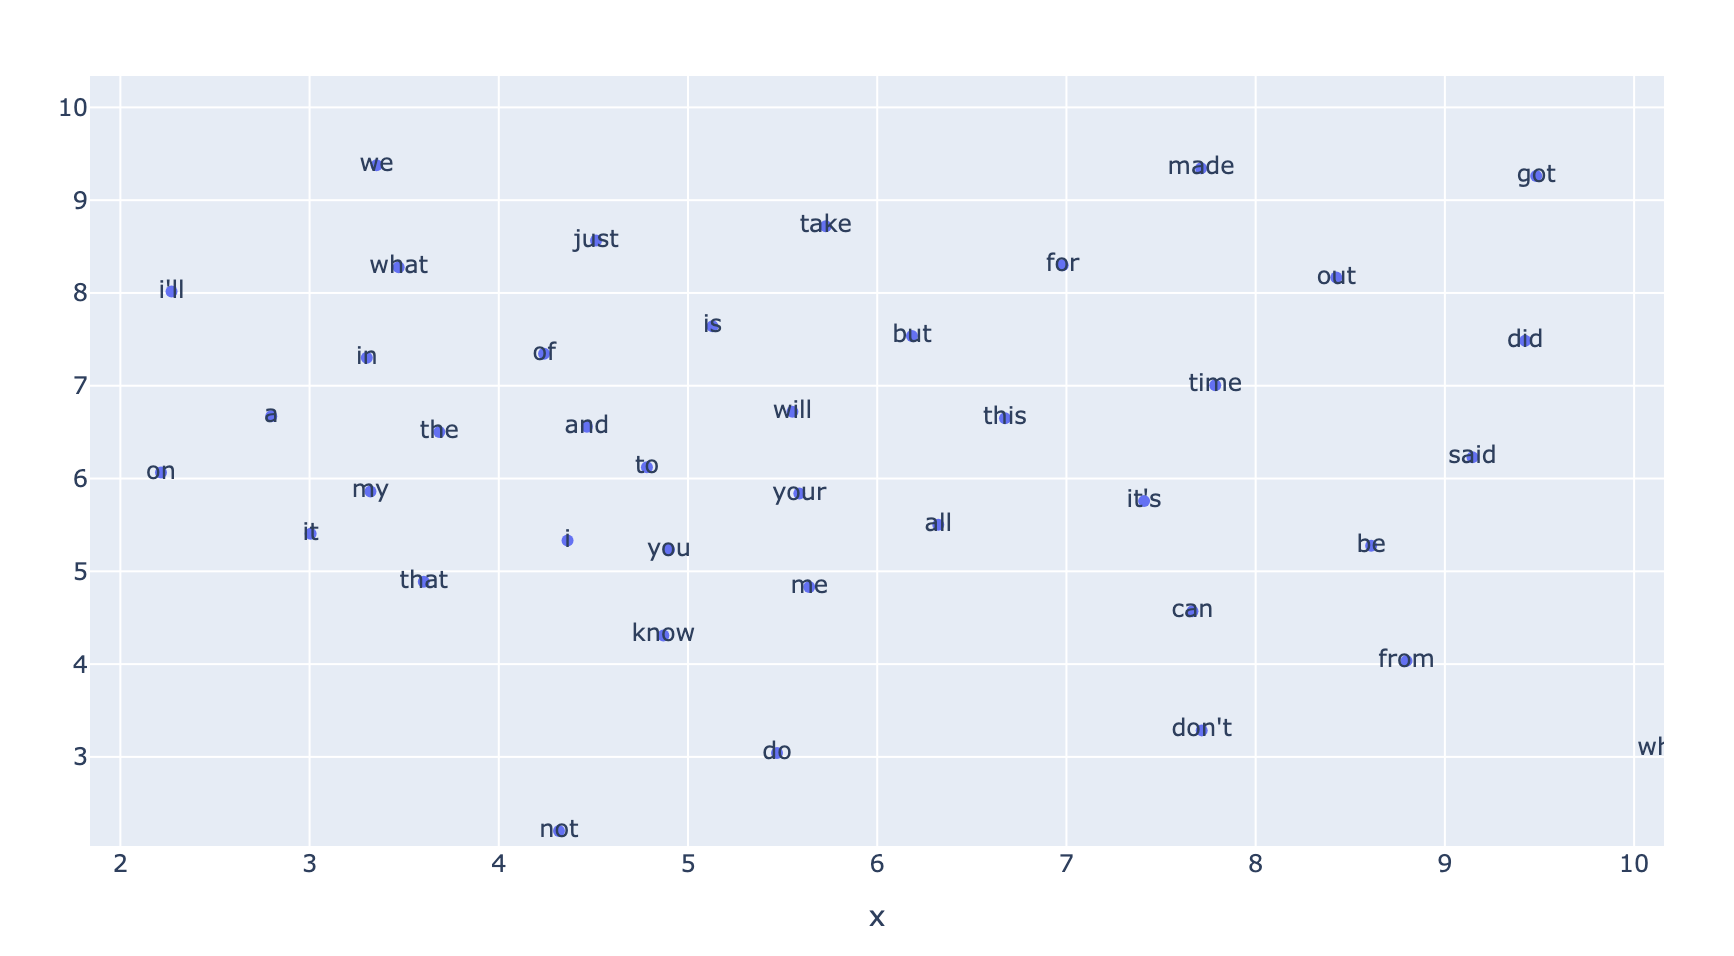

En esta imagen se pueden ver muchas palabras de uso común: pronombres, conectores, adverbios y algunos términos que son muy utilizados en *phrasal verbs*. Relaciono esto con la faceta de rap de la banda, donde muchas canciones tienen intervenciones con una gran carga de texto que es interpretado de forma muy rápida, casi hablada.

Gracias a este recurso, este tipo de palabras aparecen con mucha frecuencia en esas secciones, a diferencia de los momentos más líricos donde, para reducir un verso, se simplifica la frase y estos conectores son sacrificados a favor de la métrica.

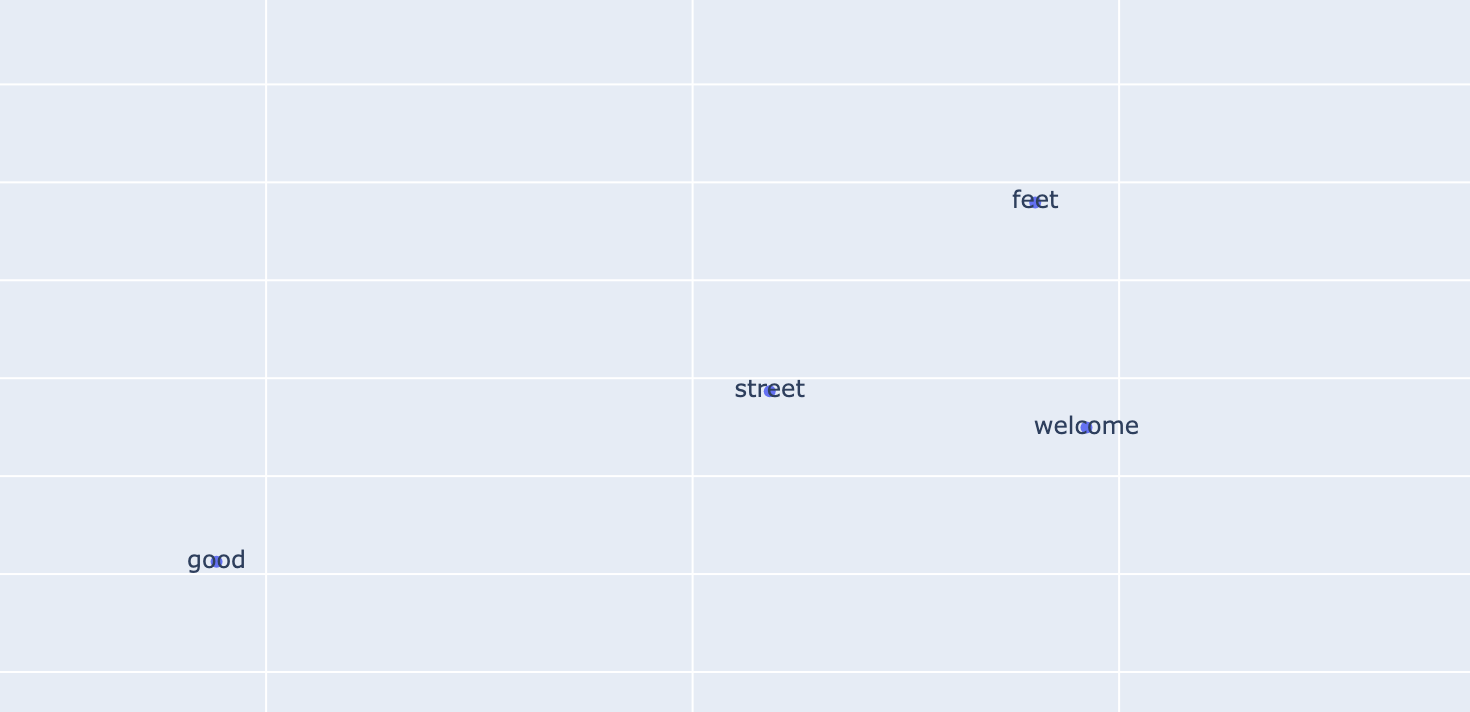

En esta imagen claramente podemos ver cómo la repetición dentro de una canción toma preponderancia. En `Mulberry Street`, frases como *"Welcome to Mulberry Street"* o *"So good to see you"* se repiten constantemente. Asimismo, el término `feet` aparece con gran frecuencia en dicha canción, consolidando su presencia en el análisis.


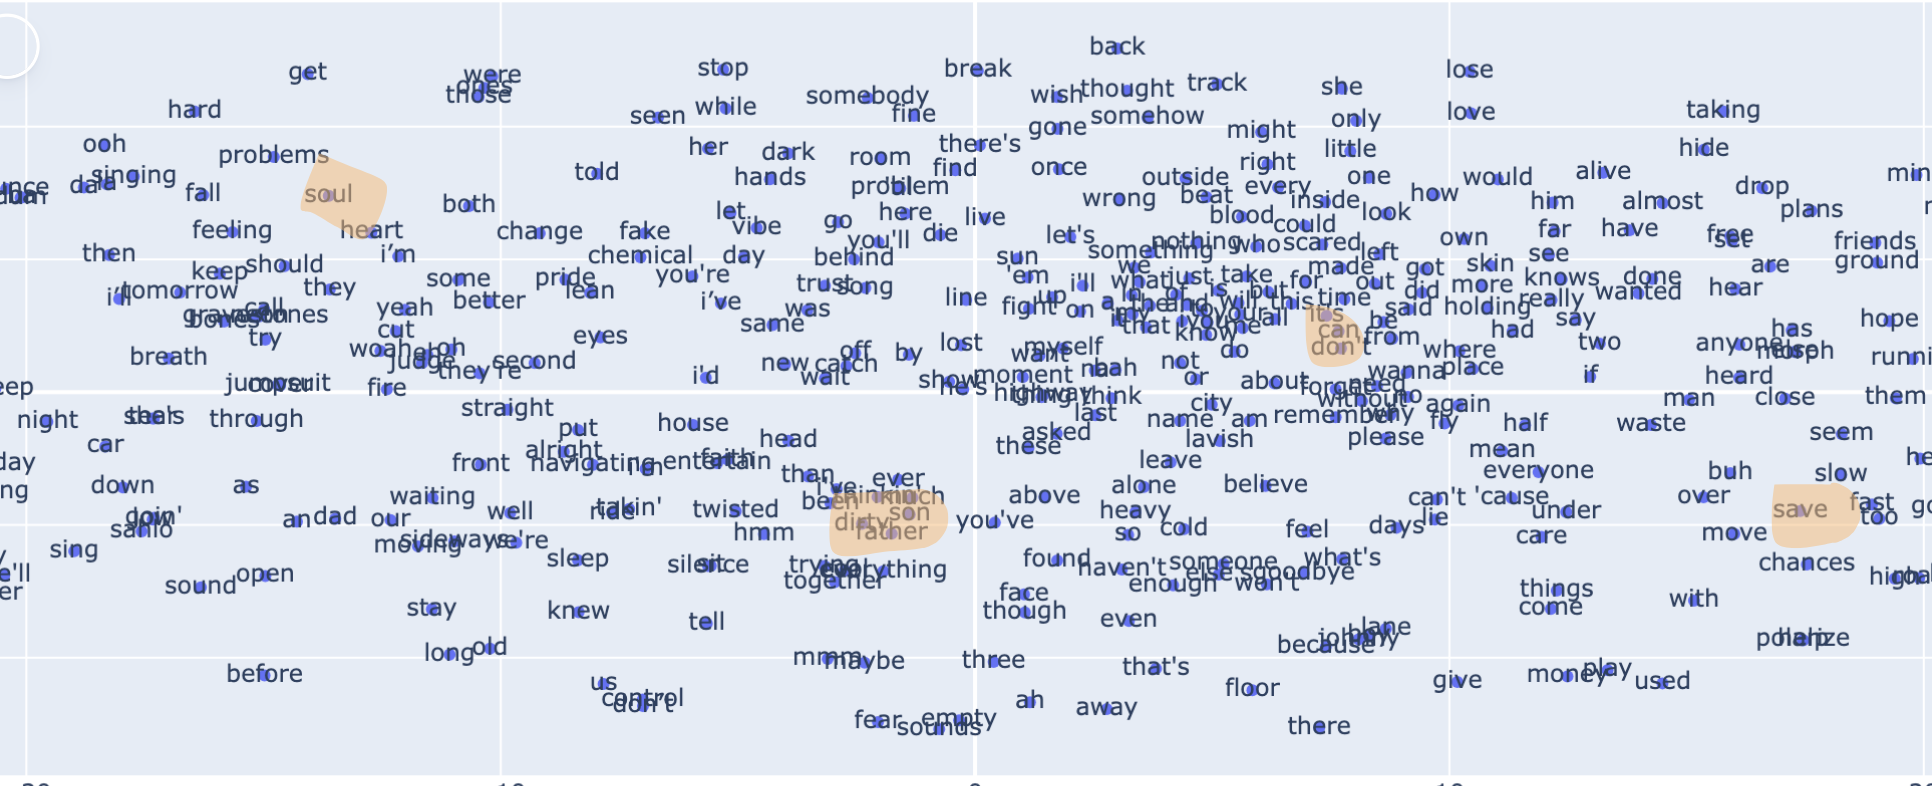

Finalmente, para este último análisis, decidí aplicar un orden inverso: tomar una frase que he cantado hasta el hartazgo y buscar su representación en el dataset. La frase elegida es: *"Can you save my heavy dirty soul"*.

Aparece más de 10 veces en la canción `Heavydirtysoul` y, para mi sorpresa, la correlación no se representó de forma tan clara: las palabras están bastante separadas unas de otras. No logré encontrar `heavy` (quizás quedó fuera del límite de las 400 palabras), pero `dirty`, `soul`, `can` y `save` aparecen a mucha distancia entre sí.

Interpreto esto como consecuencia de que `soul`, `can` y `save` aparecen en varias canciones adicionales con menor frecuencia, lo que genera un "ruido" que diluye la conexión específica de `Heavydirtysoul`. Además, la canción utiliza el recurso de construir la frase por partes (*"can you save"*, *"can you save my"*, *"can you save my heavy dirty soul"*); esto, sumado a un *window* de 4, termina alejando la conexión directa entre términos como `can` y `soul`.